In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os
import joblib

# ============================================================
# 1. Load Excel Data
# ============================================================
file_name = r'D:\Senior Project\Data\Data_Train_3_Year.xlsx'
sheets = ['Year_2023', 'Year_2024', 'Year_2025']

data_frames = []

for sheet in sheets:
    try:
        df = pd.read_excel(file_name, sheet_name=sheet)
        data_frames.append(df)
        print(f"โหลดข้อมูล {sheet} สำเร็จ: {len(df)} แถว")
    except Exception as e:
        print(f"เกิดข้อผิดพลาดในการโหลด {sheet}: {e}")

Data = pd.concat(data_frames, ignore_index=True)
Data = Data.dropna().reset_index(drop=True)

โหลดข้อมูล Year_2023 สำเร็จ: 52560 แถว
โหลดข้อมูล Year_2024 สำเร็จ: 52704 แถว
โหลดข้อมูล Year_2025 สำเร็จ: 52560 แถว


Edit

In [ ]:
# ============================================================
# 2. Feature Engineering
# ============================================================
def encode_cyclical(df, col, max_val):
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

# Cyclical Encoding
Data = encode_cyclical(Data, 'Mn', 60)
Data = encode_cyclical(Data, 'Hr', 24)
Data = encode_cyclical(Data, 'DoW', 7)
Data = encode_cyclical(Data, 'DoM', 31)
Data = encode_cyclical(Data, 'Month', 12)

# Convert Numeric
Data['IsHoliday'] = Data['IsHoliday'].astype(float)
Data['Schedule'] = Data['Schedule'].astype(float)
Data['People'] = Data['People'].astype(float)
# ============================================================
# Add Lag Features
# ============================================================
Data['lag_10'] = Data['People'].shift(1)
Data['lag_20'] = Data['People'].shift(2)
Data['lag_30'] = Data['People'].shift(3)

# ลบค่า NaN ที่เกิดจาก lag
Data = Data.dropna().reset_index(drop=True)
# ============================================================
# 3. Create Future Label
# ============================================================
Data['People_Next10'] = Data['People'].shift(-10)

# Remove NaN from shifted rows
Data = Data.dropna().reset_index(drop=True)

# ============================================================
# 4. Feature Selection
# ============================================================
features = [
    'DoW_sin', 'DoW_cos',
    'DoM_sin', 'DoM_cos',
    'Hr_sin', 'Hr_cos',
    'Mn_sin', 'Mn_cos',
    'Month_sin', 'Month_cos',
    'IsHoliday',
    'Schedule',
    'People',
    'lag_10',
    'lag_20',
    'lag_30'
]

target = 'People_Next10'

# ============================================================
# 5. Scaling
# ============================================================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

Data[features] = scaler_x.fit_transform(Data[features])
Data[[target]] = scaler_y.fit_transform(Data[[target]])

# ============================================================
# 6. Sequence Generator
# ============================================================
def create_sequences(data, feature_cols, target_col, seq_length):
    xs, ys = [], []

    data_feat = data[feature_cols].values
    data_targ = data[target_col].values

    for i in range(len(data) - seq_length):
        x = data_feat[i:i + seq_length]
        y = data_targ[i + seq_length]

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

SEQ_LENGTH = 24

X, y = create_sequences(
    Data,
    features,
    target,
    SEQ_LENGTH
)

# ============================================================
# 7. Train/Test Split
# ============================================================
train_size = int(len(X) * 0.7)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_loader = DataLoader(
    TensorDataset(
        torch.Tensor(X_train),
        torch.Tensor(y_train).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.Tensor(X_test),
        torch.Tensor(y_test).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

# ============================================================
# 8. LSTM Model
# ============================================================
class AI_TES_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(AI_TES_Model, self).__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# ============================================================
# 9. Device Setup
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = AI_TES_Model(
    input_dim=len(features),
    hidden_dim=128,
    num_layers=2,
    output_dim=1
).to(device)

# ============================================================
# 10. Training Setup
# ============================================================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200
patience = 15

best_v_loss = float('inf')
counter = 0

train_losses = []
test_losses = []

print(f"\nเริ่มการเทรนบนอุปกรณ์: {device}")

# ============================================================
# 11. Training Loop
# ============================================================
for epoch in range(epochs):

    # Training
    model.train()
    t_loss = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        t_loss += loss.item()

    # Validation
    model.eval()
    v_loss = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(outputs, batch_y)

            v_loss += loss.item()

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(test_loader)

    train_losses.append(avg_t)
    test_losses.append(avg_v)

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch+1:03d}: "
            f"Train Loss {avg_t:.6f} | "
            f"Validation Loss {avg_v:.6f}"
        )

    # Early Stopping
    if avg_v < best_v_loss:
        best_v_loss = avg_v
        torch.save(model.state_dict(), 'best_AI_TES_Model.pt')
        counter = 0
    else:
        counter += 1

        if counter >= patience:
            print(f"-- Early Stopping ที่ Epoch {epoch+1} --")
            break

# ============================================================
# 12. Visualization
# ============================================================
plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Validation Loss', color='red')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Prediction Plot
model.load_state_dict(torch.load('best_AI_TES_Model.pt'))
model.eval()

with torch.no_grad():
    sample_x = torch.Tensor(X_test).to(device)
    pred = model(sample_x).cpu().numpy()

# Reverse Scaling
pred_real = scaler_y.inverse_transform(pred)
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))

plt.subplot(1, 2, 2)

plt.plot(
    y_test_real[:150],
    label='Actual People_Next10',
    linewidth=1.5
)

plt.plot(
    pred_real[:150],
    label='Predicted People_Next10',
    linestyle='--',
    linewidth=1.5
)

plt.title('Actual vs Predicted (First 150 points)')
plt.xlabel('Time Steps')
plt.ylabel('People Count')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 13. Save Model & Scalers
# ============================================================
joblib.dump(scaler_x, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("\n--- เสร็จสิ้นกระบวนการเทรนและประเมินผล ---")
print(f"โมเดลถูกบันทึกไว้ที่: {os.getcwd()}\\best_AI_TES_Model.pt")
print(f"Scaler X ถูกบันทึกไว้ที่: {os.getcwd()}\\scaler_x.pkl")
print(f"Scaler Y ถูกบันทึกไว้ที่: {os.getcwd()}\\scaler_y.pkl")


เริ่มการเทรนบนอุปกรณ์: cpu


In [ ]:
import numpy as np
import pandas as pd

# 1. ฟังก์ชันเงื่อนไข Schedule ตามที่คุณกำหนด
def get_schedule(dow, hr):
    if dow == 1 and hr in [13, 14, 15, 16, 17]: 
        return 1.0
    if dow == 2 and hr in [8, 9, 10, 11, 12, 13, 14, 15]: 
        return 1.0
    if dow == 3 and hr in [8, 9, 10, 11, 12]: 
        return 1.0
    if dow == 4 and hr in [8, 9, 10, 11, 12, 13, 14, 15]: 
        return 1.0
    return 0.0

# 2. ตั้งค่าตัวแปรคงที่
month_val = 12
is_holiday = 0.0

rows = []

# 3. Loop สร้างข้อมูล 4 วัน (22-25 ธ.ค. 2025)
for D in range(22, 26): 
    dow_val = D - 21 # 22=1(Mon), 23=2(Tue), 24=3(Wed), 25=4(Thu)
    
    for i in range(0, 24):     # Hour (0-23)
        for j in range(0, 60, 15): # Minute (0, 15, 30, 45)
            # --- คำนวณ Cyclical Features (Sin/Cos) ---
            mn_sin = np.sin(2 * np.pi * j / 60)
            mn_cos = np.cos(2 * np.pi * j / 60)
            hr_sin = np.sin(2 * np.pi * i / 24)
            hr_cos = np.cos(2 * np.pi * i / 24)
            dow_sin = np.sin(2 * np.pi * dow_val / 7)
            dow_cos = np.cos(2 * np.pi * dow_val / 7)
            dom_sin = np.sin(2 * np.pi * D / 31)
            dom_cos = np.cos(2 * np.pi * D / 31)
            month_sin = np.sin(2 * np.pi * month_val / 12)
            month_cos = np.cos(2 * np.pi * month_val / 12)
            
            # --- เรียกใช้ฟังก์ชัน Schedule ที่สร้างไว้ ---
            current_schedule = get_schedule(dow_val, i)
            
            # --- เก็บข้อมูลเรียงตามลำดับที่ใช้เทรน ---
            rows.append({
                'Mn_sin': mn_sin,
                'Mn_cos': mn_cos,
                'Hr_sin': hr_sin,
                'Hr_cos': hr_cos,
                'DoW_sin': dow_sin,
                'DoW_cos': dow_cos,
                'DoM_sin': dom_sin,
                'DoM_cos': dom_cos,
                'Month_sin': month_sin,
                'Month_cos': month_cos,
                'IsHoliday': is_holiday,
                'Schedule': current_schedule
            })

# 4. แปลงเป็น DataFrame
df_final = pd.DataFrame(rows)

# จัดเรียงลำดับคอลัมน์ให้เป๊ะ (12 features)
features_order = [
    'Mn_sin', 'Mn_cos', 'Hr_sin', 'Hr_cos', 
    'DoW_sin', 'DoW_cos', 'DoM_sin', 'DoM_cos', 
    'Month_sin', 'Month_cos', 'IsHoliday', 'Schedule'
]
df_final = df_final[features_order]

print("--- ตรวจสอบข้อมูล 5 แถวแรก ---")
print(df_final.head()) 

# ตรวจสอบว่า Schedule ทำงานถูกต้องไหม (ตัวอย่างวันที่ 22 ช่วงบ่าย)
print("\n--- เช็ค Schedule วันจันทร์ (DoW=1) ช่วง 13:00 ---")
check = df_final[(df_final['DoM_sin'] == np.sin(2 * np.pi * 22 / 31)) & 
                 (df_final['Hr_sin'] == np.sin(2 * np.pi * 13 / 24))]
print(check[['Schedule']].head(1)) # ควรแสดงค่า 1.0

--- ตรวจสอบข้อมูล 5 แถวแรก ---
         Mn_sin        Mn_cos    Hr_sin    Hr_cos   DoW_sin  DoW_cos  \
0  0.000000e+00  1.000000e+00  0.000000  1.000000  0.781831  0.62349   
1  1.000000e+00  2.832769e-16  0.000000  1.000000  0.781831  0.62349   
2  5.665539e-16 -1.000000e+00  0.000000  1.000000  0.781831  0.62349   
3 -1.000000e+00 -1.836970e-16  0.000000  1.000000  0.781831  0.62349   
4  0.000000e+00  1.000000e+00  0.258819  0.965926  0.781831  0.62349   

    DoM_sin   DoM_cos     Month_sin  Month_cos  IsHoliday  Schedule  
0 -0.968077 -0.250653 -2.449294e-16        1.0        0.0       0.0  
1 -0.968077 -0.250653 -2.449294e-16        1.0        0.0       0.0  
2 -0.968077 -0.250653 -2.449294e-16        1.0        0.0       0.0  
3 -0.968077 -0.250653 -2.449294e-16        1.0        0.0       0.0  
4 -0.968077 -0.250653 -2.449294e-16        1.0        0.0       0.0  

--- เช็ค Schedule วันจันทร์ (DoW=1) ช่วง 13:00 ---
    Schedule
52       1.0


--- การพยากรณ์เสร็จสิ้น ---
ได้ผลทำนายทั้งหมด: 360 ช่วงเวลา


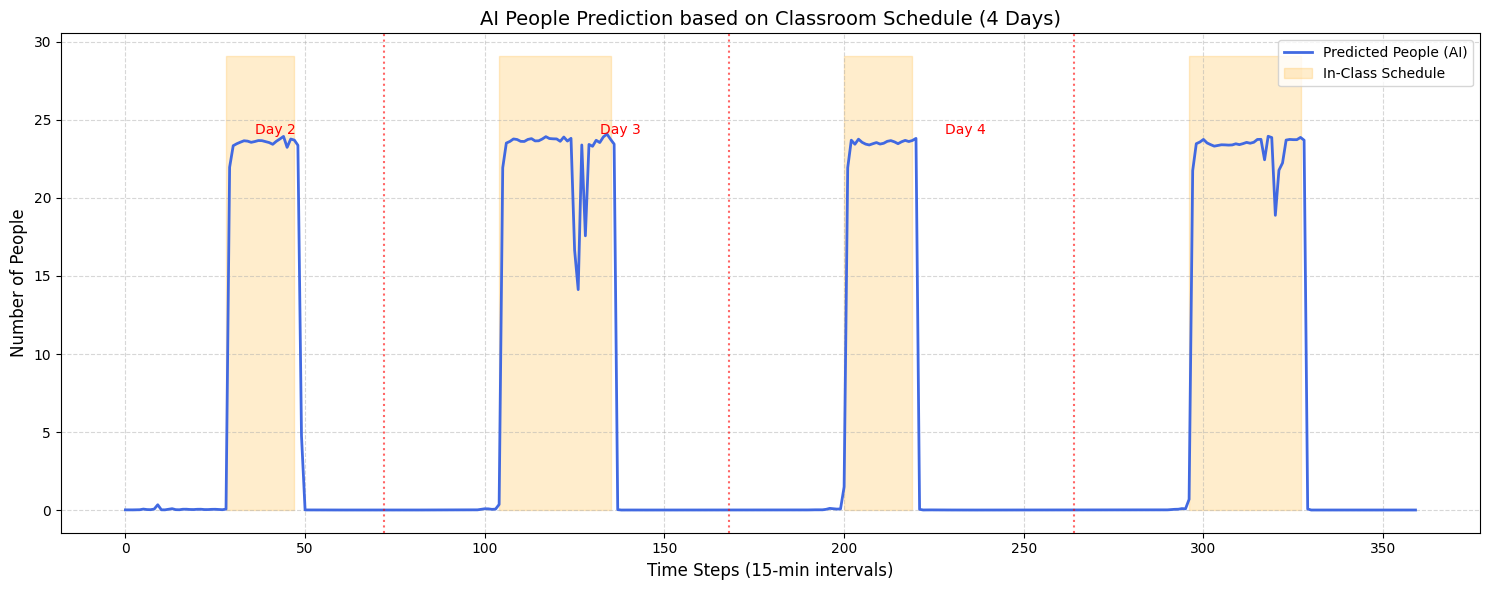

จำนวนคนสูงสุดที่ทำนายได้: 24.10 คน
จำนวนคนเฉลี่ยขณะมีเรียน: 22.37 คน


In [ ]:
import torch

# 1. โหลดโมเดลที่เทรนไว้แล้ว
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AI_TES_Model(input_dim=12, hidden_dim=64, num_layers=2, output_dim=1).to(device)
model.load_state_dict(torch.load('best_AI_TES_Model.pt')) # ดึงไฟล์ที่เทรนไว้มาใช้
model.eval()

# 2. Scaling ข้อมูลใหม่ (ใช้ scaler_x ที่รันไว้ตอนเทรน)
# ห้ามใช้ fit_transform ให้ใช้แค่ transform
X_new_scaled = scaler_x.transform(df_final[features_order]) 

# 3. จัดรูปแบบเป็น Sequence (Windowing)
def create_test_sequences(data, seq_len):
    xs = []
    for i in range(len(data) - seq_len):
        x = data[i:(i + seq_len)]
        xs.append(x)
    return np.array(xs)

# หั่นข้อมูลเป็นก้อนละ 24 เพื่อให้โมเดลอ่านอดีตก่อนทาย
X_seq = create_test_sequences(X_new_scaled, seq_len=24)
X_tensor = torch.Tensor(X_seq).to(device)

# 4. เริ่มการ Predict
with torch.no_grad():
    predictions_scaled = model(X_tensor).cpu().numpy()

# 5. แปลงค่ากลับเป็น "จำนวนคน" (Inverse Transform)
# ใช้ scaler_y ตัวเดิมที่เคย fit กับค่า People ตอนเทรน
predictions_real = scaler_y.inverse_transform(predictions_scaled)

print("--- การพยากรณ์เสร็จสิ้น ---")
print(f"ได้ผลทำนายทั้งหมด: {len(predictions_real)} ช่วงเวลา")
import matplotlib.pyplot as plt

# 1. จัดเตรียมข้อมูลสำหรับพล็อต
# เนื่องจาก Windowing (SEQ_LENGTH=24) ทำให้ข้อมูลหายไป 24 แถวแรก
# เราจึงต้องตัดตารางเรียน (Schedule) ให้เริ่มที่ตำแหน่งเดียวกับผล Prediction
schedule_plot = df_final['Schedule'].values[24:] 
time_axis = range(len(predictions_real)) # สร้างแกน X ตามจำนวนที่ทายได้

plt.figure(figsize=(15, 6))

# --- พล็อตเส้นจำนวนคนที่ AI ทำนาย ---
plt.plot(time_axis, predictions_real, label='Predicted People (AI)', color='royalblue', linewidth=2)

# --- พล็อตแถบสีเทา (Background) เฉพาะช่วงที่มีตารางเรียน (Schedule = 1) ---
# เพื่อดูว่า AI ทายสอดคล้องกับตารางเรียนไหม
plt.fill_between(time_axis, 0, max(predictions_real)+5, 
                 where=(schedule_plot == 1), 
                 color='orange', alpha=0.2, label='In-Class Schedule')

# --- ตกแต่งกราฟ ---
plt.title('AI People Prediction based on Classroom Schedule (4 Days)', fontsize=14)
plt.xlabel('Time Steps (15-min intervals)', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# แสดงเส้นแบ่งวัน (ทุกๆ 96 สเต็ป คือ 1 วัน: 24 ชม. * 4 ครั้ง/ชม.)
for d in range(1, 4):
    plt.axvline(x=d*96 - 24, color='red', linestyle=':', alpha=0.6)
    plt.text(d*96 - 60, max(predictions_real), f'Day {d+1}', color='red')

plt.tight_layout()
plt.show()

# 2. แสดงค่าสถิติเบื้องต้น
print(f"จำนวนคนสูงสุดที่ทำนายได้: {predictions_real.max():.2f} คน")
print(f"จำนวนคนเฉลี่ยขณะมีเรียน: {predictions_real[schedule_plot == 1].mean():.2f} คน")

--- ผลการทดสอบความแม่นยำ ---
RMSE: 9.5808 (พลาดเฉลี่ยประมาณ 9.58 คน)
R-squared: -0.4456 (เข้าใกล้ 1 คือแม่นยำมาก)


C:\Users\acer\AppData\Local\Temp\ipykernel_8228\3253584287.py:19: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_actual_15min = df_actual_all['NumberPeople'].resample('15T').mean().dropna()
C:\Users\acer\AppData\Local\Temp\ipykernel_8228\3253584287.py:35: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100


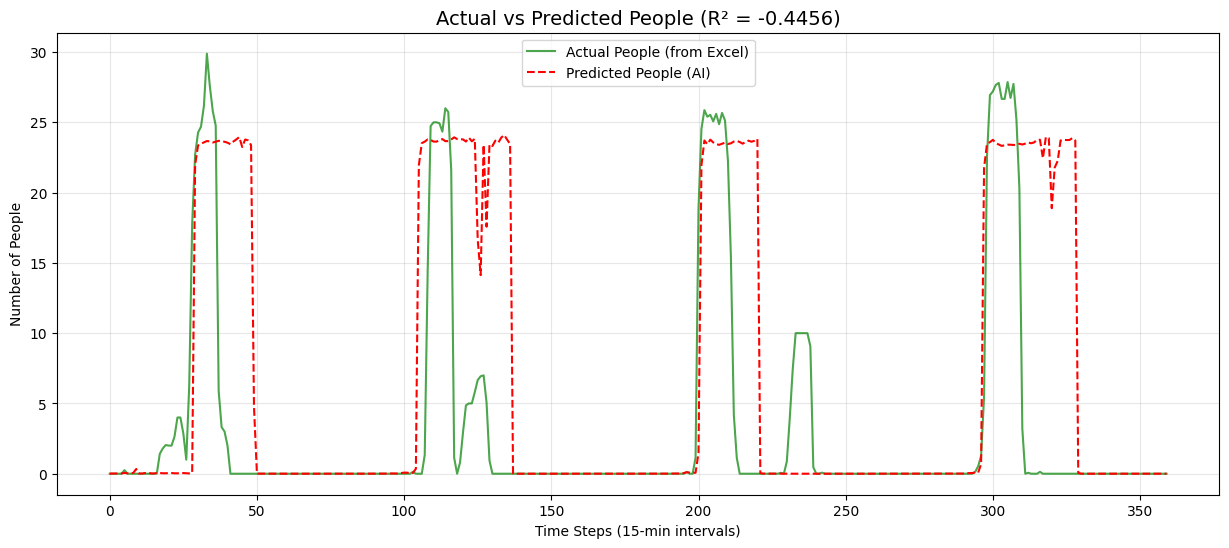

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  # เผื่อว่ายังไม่ได้ import np สำหรับใช้ np.sqrt
# 1. จัดการข้อมูลจริง (Actual Data) จากไฟล์ Excel ให้เป็นราย 15 นาที
file_room = r'D:\Senior Project\Data\Classromm_Data.xlsx'
sheets = ['22-12-2025', '23-12-2025', '24-12-2025', '25-12-2025']

actual_raw = []
for sheet in sheets:
    df = pd.read_excel(file_room, sheet_name=sheet)
    df['Timestamp'] = pd.to_datetime(sheet + ' ' + 
                                     df['Hour'].astype(str).str.zfill(2) + ':' + 
                                     df['Minute'].astype(str).str.zfill(2) + ':' + 
                                     df['Second'].astype(str).str.zfill(2), 
                                     format='%d-%m-%Y %H:%M:%S')
    actual_raw.append(df)

df_actual_all = pd.concat(actual_raw).set_index('Timestamp')
# ยุบข้อมูลจริงเป็นราย 15 นาที (ต้องทำเหมือนตอนเตรียมข้อมูล Predict)
df_actual_15min = df_actual_all['NumberPeople'].resample('15T').mean().dropna()

# 2. ปรับขนาดข้อมูลให้เท่ากัน
# เนื่องจาก Predict จะหายไป 24 สเต็ปแรก (จาก SEQ_LENGTH) 
# เราจึงต้องตัดข้อมูลจริงออก 24 สเต็ปแรกด้วยเพื่อให้ Index ตรงกัน
actual_values = df_actual_15min.values[24:] 
predicted_values = predictions_real.flatten() # ค่าที่ได้จากโมเดลก่อนหน้านี้

# ตรวจสอบว่าจำนวนข้อมูลเท่ากันไหม
min_len = min(len(actual_values), len(predicted_values))
actual_values = actual_values[:min_len]
predicted_values = predicted_values[:min_len]

# 3. คำนวณความแม่นยำ
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
r2 = r2_score(actual_values, predicted_values)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print(f"--- ผลการทดสอบความแม่นยำ ---")
print(f"RMSE: {rmse:.4f} (พลาดเฉลี่ยประมาณ {rmse:.2f} คน)")
print(f"R-squared: {r2:.4f} (เข้าใกล้ 1 คือแม่นยำมาก)")

# 4. พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(15, 6))
plt.plot(actual_values, label='Actual People (from Excel)', color='green', alpha=0.7)
plt.plot(predicted_values, label='Predicted People (AI)', color='red', linestyle='--')

plt.title(f'Actual vs Predicted People (R² = {r2:.4f})', fontsize=14)
plt.ylabel('Number of People')
plt.xlabel('Time Steps (15-min intervals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()